# Trabalho Final | Ciência de Dados

## Escolha da base de dados
Resumo da Base de Dados "Adult" (Census Income)
1. **Objetivo Principal**:
O propósito central desta base de dados é uma tarefa de classificação: prever se o rendimento anual de um indivíduo excede $50.000 com base em um conjunto de informações extraídas do censo demográfico. Também é conhecida como "Census Income".

2. **Origem dos Dados**:
Os dados foram extraídos do banco de dados do censo de 1994 dos Estados Unidos por Barry Becker. Foram aplicados alguns filtros para criar um conjunto de registros "limpos", como por exemplo, considerar apenas pessoas com mais de 16 anos e com um ganho de capital ajustado maior que 100.


**Estrutura da Base**:

* **Instâncias**: A base de dados completa possui 48.842 registros (indivíduos).

* **Atributos (Colunas)**: São 14 atributos (ou features) utilizados para fazer a previsão e 1 atributo alvo (a classe).

In [ ]:
import pandas as pd

# URL do arquivo de dados
url_adult = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'

# Nomes das colunas (conforme a documentação)
# É crucial adicionar os nomes manualmente, pois o arquivo .data não os possui.
colunas_adult = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

# Carregar os dados usando pandas
# O separador é ', ' (vírgula seguido de espaço) e o arquivo não tem cabeçalho (header=None).
# O parâmetro na_values é usado para que os valores ' ?' sejam reconhecidos como dados faltantes (NaN).
df_adult = pd.read_csv(url_adult, header=None, names=colunas_adult,
                       sep=r'\s*,\s*', engine='python', na_values='?')

# Visualizar as primeiras 5 linhas para confirmar que carregou corretamente
print("Base de Dados Adult (Census Income):")
print(df_adult.head())

# Verificar as informações gerais e a contagem de dados faltantes
print("\nInformações da base Adult:")
df_adult.info()

Base de Dados Adult (Census Income):
   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital-gain  capital-loss  hours-per-week native-country income  
0          2174             0              40  United-States  <=50K  
1    

## Exploração dos dados

Verificar os tipos de dados, a presença de valores ausentes e estatísticas descritivas para entender a distribuição dos atributos numéricos e categóricos.



In [ ]:
# Exibir os tipos de dados
print("Tipos de dados das colunas:")
print(df_adult.dtypes)

# Contar valores ausentes
print("\nContagem de valores ausentes por coluna:")
print(df_adult.isnull().sum())

# Estatísticas descritivas para colunas numéricas
print("\nEstatísticas descritivas para colunas numéricas:")
display(df_adult.describe())

# Estatísticas descritivas para colunas categóricas
print("\nEstatísticas descritivas para colunas categóricas:")
display(df_adult.describe(include='object'))

Tipos de dados das colunas:
age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
income            object
dtype: object

Contagem de valores ausentes por coluna:
age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

Estatísticas descritivas para colunas numéricas:


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000



Estatísticas descritivas para colunas categóricas:


,workclass,education,marital-status,occupation,relationship,race,sex,native-country,income
count,30725,32561,32561,30718,32561,32561,32561,31978,32561
unique,8,16,7,14,6,5,2,41,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,22696,10501,14976,4140,13193,27816,21790,29170,24720


### Identificação do atributo classe

Confirmar qual coluna representa a variável alvo (income) e verificar a distribuição das classes para identificar se o problema é desbalanceado.


In [ ]:
# Acessar a coluna 'income' e contar a frequência de cada valor único
income_counts = df_adult['income'].value_counts()

# Imprimir a contagem de valores
print("Distribuição da variável alvo 'income':")
print(income_counts)

## Pré-processamento
### Analisando e Tratando Valores Missing

Detalhar a análise dos valores ausentes, identificando as colunas afetadas, seus tipos de dados e a estratégia de tratamento utilizada.

Com base nas análises realizadas:

**Valores Ausentes:** Identificamos a presença de valores ausentes em três colunas categóricas: 'workclass' (1836 valores ausentes), 'occupation' (1843 valores ausentes) e 'native-country' (583 valores ausentes). As demais colunas não apresentaram dados faltantes.

**Tipos de Dados das Colunas com Valores Ausentes:** Conforme verificado, as colunas 'workclass', 'occupation' e 'native-country' são do tipo `object`, indicando que contêm dados categóricos.

**Tratamento de Valores Ausentes:** Para lidar com os valores ausentes nestas colunas categóricas, optamos pela estratégia de **imputação pela moda**. Ou seja, os valores faltantes em cada uma dessas colunas foram substituídos pelo valor mais frequente observado na respectiva coluna.

**Impacto do One-Hot Encoding:** Após a imputação dos valores ausentes, vamos aplicar o **One-Hot Encoding** nas colunas categóricas (excluindo a variável alvo 'income'). Esta técnica transformou cada categoria única dentro dessas colunas em uma nova coluna binária (0 ou 1). Como resultado, o número total de colunas no DataFrame aumentou significativamente, passando das 15 colunas originais (6 numéricas e 9 categóricas) para 98 colunas (6 numéricas, 1 coluna alvo e 91 colunas booleanas resultantes do encoding), conforme observado nas informações do DataFrame após o encoding.

In [ ]:
# Verificar os tipos de dados das colunas com valores ausentes
cols_with_missing = ['workclass', 'occupation', 'native-country']
print("Tipos de dados das colunas com valores ausentes:")
print(df_adult[cols_with_missing].dtypes)

# Contar valores únicos e suas frequências para entender a natureza dos dados faltantes
print("\nContagem de valores para 'workclass':")
print(df_adult['workclass'].value_counts(dropna=False))

print("\nContagem de valores para 'occupation':")
print(df_adult['occupation'].value_counts(dropna=False))

print("\nContagem de valores para 'native-country':")
print(df_adult['native-country'].value_counts(dropna=False))

Tipos de dados das colunas com valores ausentes:
workclass         object
occupation        object
native-country    object
dtype: object

Contagem de valores para 'workclass':
workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
NaN                  1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

Contagem de valores para 'occupation':
occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4066
Adm-clerical         3770
Sales                3650
Other-service        3295
Machine-op-inspct    2002
NaN                  1843
Transport-moving     1597
Handlers-cleaners    1370
Farming-fishing       994
Tech-support          928
Protective-serv       649
Priv-house-serv       149
Armed-Forces            9
Name: count, dtype: int64

Contagem de valores para 'native-country':
native-country
United-States              

In [ ]:
# Imputar valores ausentes com a moda
for col in cols_with_missing:
    mode_value = df_adult[col].mode()[0]
    df_adult[col] = df_adult[col].fillna(mode_value)

print("Contagem de valores ausentes após imputação:")
print(df_adult.isnull().sum())

Contagem de valores ausentes após imputação:
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


In [ ]:
# Aplicar One-Hot Encoding nas colunas categóricas
# Identificar colunas categóricas (excluindo a coluna alvo 'income')
categorical_cols = df_adult.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('income') # Excluir a coluna alvo

df_adult_encoded = pd.get_dummies(df_adult, columns=categorical_cols, drop_first=True)

print("Primeiras 5 linhas do DataFrame após One-Hot Encoding:")
display(df_adult_encoded.head())

print("\nInformações do DataFrame após One-Hot Encoding:")
df_adult_encoded.info()

Primeiras 5 linhas do DataFrame após One-Hot Encoding:


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,39,77516,13,2174,0,40,<=50K,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,50,83311,13,0,0,13,<=50K,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,38,215646,9,0,0,40,<=50K,False,False,True,...,False,False,False,False,False,False,False,True,False,False
3,53,234721,7,0,0,40,<=50K,False,False,True,...,False,False,False,False,False,False,False,True,False,False
4,28,338409,13,0,0,40,<=50K,False,False,True,...,False,False,False,False,False,False,False,False,False,False



Informações do DataFrame após One-Hot Encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 98 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   age                                        32561 non-null  int64 
 1   fnlwgt                                     32561 non-null  int64 
 2   education-num                              32561 non-null  int64 
 3   capital-gain                               32561 non-null  int64 
 4   capital-loss                               32561 non-null  int64 
 5   hours-per-week                             32561 non-null  int64 
 6   income                                     32561 non-null  object
 7   workclass_Local-gov                        32561 non-null  bool  
 8   workclass_Never-worked                     32561 non-null  bool  
 9   workclass_Private                          32561 non-nul

In [ ]:
# 1. Resumir os atributos chave e tipos de dados
print("Atributos Chave e Tipos de Dados:")
print(df_adult_encoded.dtypes) # Usar o DataFrame codificado para refletir os tipos após o encoding

# 2. Descrever valores ausentes e seu tratamento
print("\nValores ausentes por coluna:")
print(df_adult.isnull().sum()) # Usar o DataFrame original para mostrar os ausentes antes do tratamento
print("\nValores ausentes foram identificados nas colunas 'workclass', 'occupation' e 'native-country'.")
print("Estes foram imputados com a moda de suas respectivas colunas.") # Adicionar a informação sobre o tratamento

# 3. Confirmar 'income' como a variável alvo e descrever seus valores e desbalanceamento
print("\nVariável Alvo: 'income'")
print("Valores únicos de 'income':")
print(df_adult['income'].unique())
print("\nDistribuição de 'income':")
income_counts = df_adult['income'].value_counts()
print(income_counts)

# 4. Declarar se o problema é balanceado ou desbalanceado
print("\nBalanceamento de Classe:")
if income_counts.min() / income_counts.max() < 0.5: # Limiar simples para desbalanceamento
    print("O problema é desbalanceado, pois o número de instâncias para as duas classes ('<=50K' e '>50K') é significativamente diferente.")
else:
    print("O problema é relativamente balanceado.")

Atributos Chave e Tipos de Dados:
age                               int64
fnlwgt                            int64
education-num                     int64
capital-gain                      int64
capital-loss                      int64
                                  ...  
native-country_Thailand            bool
native-country_Trinadad&Tobago     bool
native-country_United-States       bool
native-country_Vietnam             bool
native-country_Yugoslavia          bool
Length: 98, dtype: object

Valores ausentes por coluna:
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

Valores ausentes foram identificados nas colunas 'workclass', 'occupation' e 'native-country'.
Estes foram imputados com a moda de suas respectivas colunas.

### Visualização dos dados


Foi criado gráficos (como histogramas, box plots ou gráficos de barras) para visualizar a distribuição de atributos importantes e suas relações com a variável alvo.


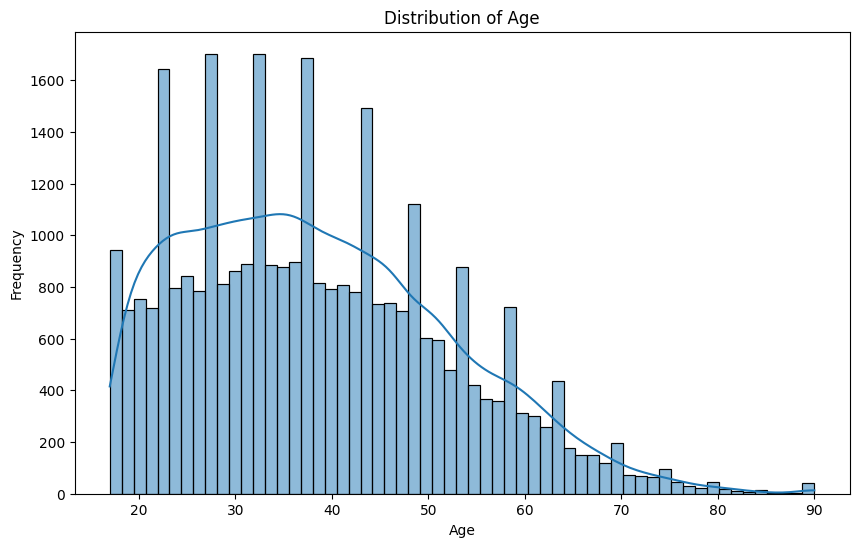

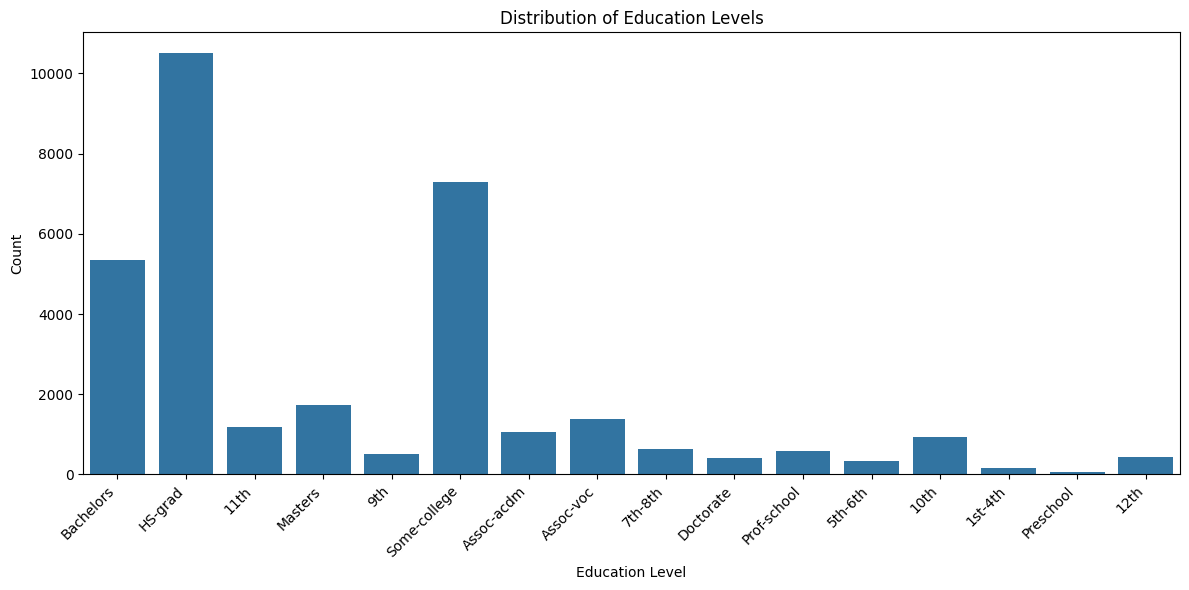

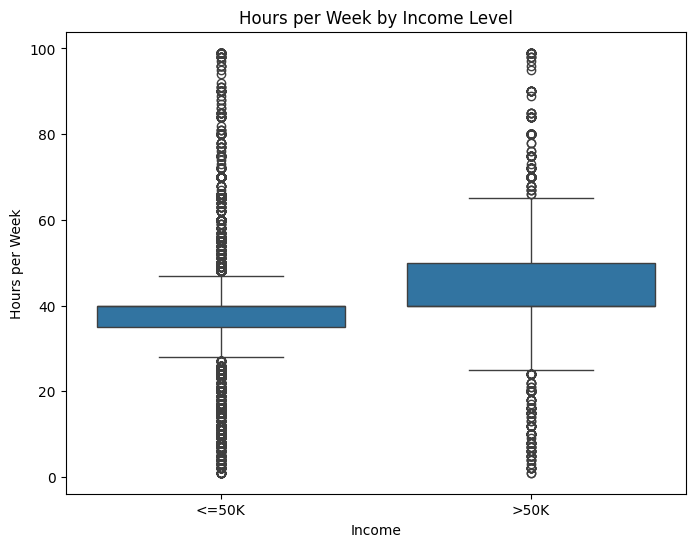

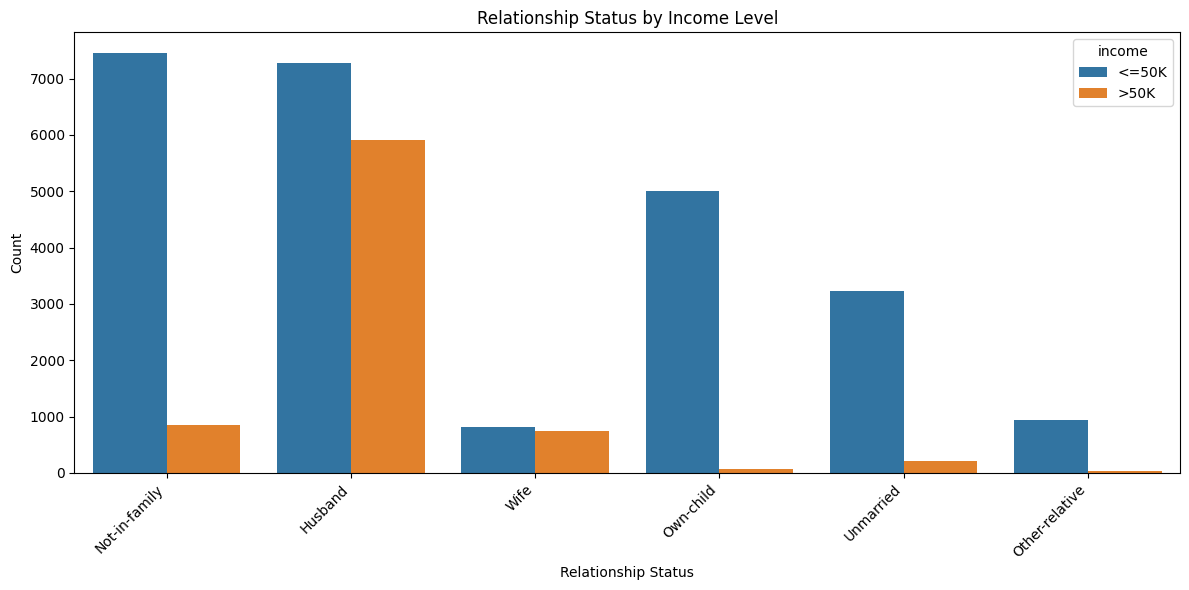

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Histogram para a coluna 'age'
plt.figure(figsize=(10, 6))
sns.histplot(df_adult['age'], kde=True)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Age')
plt.show()

# 4. Create a countplot for the 'education' column
plt.figure(figsize=(12, 6))
sns.countplot(x='education', data=df_adult)
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.title('Distribution of Education Levels')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 5. Create a box plot for 'hours-per-week' versus 'income'
plt.figure(figsize=(8, 6))
sns.boxplot(x='income', y='hours-per-week', data=df_adult)
plt.xlabel('Income')
plt.ylabel('Hours per Week')
plt.title('Hours per Week by Income Level')
plt.show()

# 6. Create a countplot for 'relationship' versus 'income'
plt.figure(figsize=(12, 6))
sns.countplot(x='relationship', hue='income', data=df_adult)
plt.xlabel('Relationship Status')
plt.ylabel('Count')
plt.title('Relationship Status by Income Level')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Observações das visualizações

Observações das Visualizações:
1. A distribuição de idade é inclinada para indivíduos mais jovens.
2. A distribuição de renda é fortemente inclinada para a classe '<=50K', confirmando o desbalanceamento.
3. Os níveis de 'Education' mostram uma distribuição diversa, sendo 'HS-grad' o mais frequente."
4. O box plot de 'hours-per-week' por 'income' sugere que indivíduos ganhando mais que 50K tendem a trabalhar mais horas por semana em média."
5. O countplot de 'relationship' por 'income' indica que certos status de relacionamento (por exemplo, 'Husband') são mais prevalentes no grupo de renda '>50K', enquanto outros (por exemplo, 'Not-in-family', 'Unmarried') são mais comuns no grupo '<=50K'.

## Algoritmo de classificação

 Divisão dos dados em treino e teste


In [ ]:
from sklearn.model_selection import train_test_split

# Separar features (X) da variável alvo (y)
X = df_adult_encoded.drop('income', axis=1)
y = df_adult_encoded['income']

# Dividir os dados em treino e teste (por exemplo, 80% treino, 20% teste)
# Usamos stratify=y para garantir que a proporção da variável alvo seja a mesma nos conjuntos de treino e teste,
# o que é importante dado o desbalanceamento.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape dos dados de treino (X_train, y_train):", X_train.shape, y_train.shape)
print("Shape dos dados de teste (X_test, y_test):", X_test.shape, y_test.shape)

Shape dos dados de treino (X_train, y_train): (26048, 97) (26048,)
Shape dos dados de teste (X_test, y_test): (6513, 97) (6513,)


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Inicializar os modelos
naive_bayes_model = GaussianNB()
knn_model = KNeighborsClassifier()
random_forest_model = RandomForestClassifier(random_state=42)

# Treinar o modelo Naive Bayes
print("Treinando o modelo Naive Bayes...")
naive_bayes_model.fit(X_train, y_train)
print("Treinamento do Naive Bayes concluído.")

# Treinar o modelo K-Nearest Neighbors
print("\nTreinando o modelo K-Nearest Neighbors...")
knn_model.fit(X_train, y_train)
print("Treinamento do K-Nearest Neighbors concluído.")

# Treinar o modelo Random Forest
print("\nTreinando o modelo Random Forest...")
random_forest_model.fit(X_train, y_train)
print("Treinamento do Random Forest concluído.")

Treinando o modelo Naive Bayes...
Treinamento do Naive Bayes concluído.

Treinando o modelo K-Nearest Neighbors...
Treinamento do K-Nearest Neighbors concluído.

Treinando o modelo Random Forest...
Treinamento do Random Forest concluído.


In [ ]:
# Avaliar o modelo Naive Bayes
print("Avaliando o modelo Naive Bayes...")
y_pred_nb = naive_bayes_model.predict(X_test)
print("Acurácia (Naive Bayes):", accuracy_score(y_test, y_pred_nb))
print("Relatório de Classificação (Naive Bayes):\n", classification_report(y_test, y_pred_nb))
print("Matriz de Confusão (Naive Bayes):\n", confusion_matrix(y_test, y_pred_nb))

# Avaliar o modelo K-Nearest Neighbors
print("\nAvaliando o modelo K-Nearest Neighbors...")
y_pred_knn = knn_model.predict(X_test)
print("Acurácia (K-Nearest Neighbors):", accuracy_score(y_test, y_pred_knn))
print("Relatório de Classificação (K-Nearest Neighbors):\n", classification_report(y_test, y_pred_knn))
print("Matriz de Confusão (K-Nearest Neighbors):\n", confusion_matrix(y_test, y_pred_knn))

# Avaliar o modelo Random Forest
print("\nAvaliando o modelo Random Forest...")
y_pred_rf = random_forest_model.predict(X_test)
print("Acurácia (Random Forest):", accuracy_score(y_test, y_pred_rf))
print("Relatório de Classificação (Random Forest):\n", classification_report(y_test, y_pred_rf))
print("Matriz de Confusão (Random Forest):\n", confusion_matrix(y_test, y_pred_rf))

Avaliando o modelo Naive Bayes...
Acurácia (Naive Bayes): 0.799324428066943
Relatório de Classificação (Naive Bayes):
               precision    recall  f1-score   support

       <=50K       0.81      0.95      0.88      4945
        >50K       0.68      0.32      0.43      1568

    accuracy                           0.80      6513
   macro avg       0.75      0.63      0.66      6513
weighted avg       0.78      0.80      0.77      6513

Matriz de Confusão (Naive Bayes):
 [[4708  237]
 [1070  498]]

Avaliando o modelo K-Nearest Neighbors...
Acurácia (K-Nearest Neighbors): 0.7822815906648242
Relatório de Classificação (K-Nearest Neighbors):
               precision    recall  f1-score   support

       <=50K       0.81      0.92      0.87      4945
        >50K       0.58      0.33      0.43      1568

    accuracy                           0.78      6513
   macro avg       0.70      0.63      0.65      6513
weighted avg       0.76      0.78      0.76      6513

Matriz de Confusão (

### Comparativo de Desempenho dos Modelos

Com base nos resultados da avaliação nos dados de teste, podemos comparar o desempenho dos três modelos:

**Naive Bayes:**
*   **Acurácia:** Aproximadamente 79.9%
*   **Relatório de Classificação:**
    *   Classe `<=50K` (Majoritária): Alta precisão, recall e F1-score.
    *   Classe `>50K` (Minoritária): Precisão razoável, mas baixo recall e F1-score, indicando dificuldade em identificar corretamente a maioria das instâncias da classe minoritária.
*   **Matriz de Confusão:** Mostra um número significativo de falsos negativos (instâncias `>50K` classificadas como `<=50K`).

**K-Nearest Neighbors:**
*   **Acurácia:** Aproximadamente 78.2%
*   **Relatório de Classificação:**
    *   Classe `<=50K` (Majoritária): Boas métricas.
    *   Classe `>50K` (Minoritária): Precisão baixa e baixo recall e F1-score, similar ao Naive Bayes, com dificuldade em capturar a classe minoritária.
*   **Matriz de Confusão:** Também apresenta um número considerável de falsos negativos.

**Random Forest:**
*   **Acurácia:** Aproximadamente 85.9%
*   **Relatório de Classificação:**
    *   Classe `<=50K` (Majoritária): Ótimas métricas.
    *   Classe `>50K` (Minoritária): Precisão e recall significativamente melhores em comparação com Naive Bayes e KNN, resultando em um F1-score mais alto para a classe minoritária.
*   **Matriz de Confusão:** O número de falsos negativos é menor em comparação com os outros dois modelos.

**Conclusão Parcial:**

Considerando as métricas, especialmente o desempenho na classe minoritária (`>50K`), o modelo **Random Forest** apresentou o melhor desempenho entre os três algoritmos testados. Ele conseguiu um melhor equilíbrio entre precisão e recall para a classe de interesse (renda > 50K), o que é crucial em problemas de classificação desbalanceados onde a identificação correta da classe minoritária é frequentemente o objetivo principal.

## Avaliação dos algoritmos

### Etapa 1: Preparação do Ambiente e Definição da Estratégia de Avaliação

Antes de prosseguirmos com a execução dos algoritmos, é fundamental definirmos e justificarmos a estratégia que utilizaremos para avaliar o desempenho dos modelos. Uma avaliação robusta é crucial para garantir que os resultados sejam confiáveis e reflitam a real capacidade de generalização dos modelos para dados não vistos.

### Justificativa da Validação Cruzada Estratificada

Para avaliar nossos modelos, optaremos pela **Validação Cruzada Estratificada com 10 folds**. A validação cruzada é uma técnica amplamente utilizada para estimar o desempenho de um modelo em dados independentes, dividindo o dataset em múltiplos subconjuntos (folds). O modelo é treinado em uma combinação desses folds e avaliado no fold restante, repetindo-se o processo até que cada fold tenha sido usado como conjunto de teste.

A escolha da versão **Estratificada** é particularmente importante neste projeto devido ao **desbalanceamento da classe alvo ('income')** na base de dados Adult. Como observamos, há uma quantidade significativamente maior de indivíduos na classe '<=50K' em comparação com a classe '>50K'. A estratificação garante que, em cada divisão (fold) da validação cruzada, a proporção das classes seja preservada. Isso evita que um fold de teste contenha, por exemplo, muito poucas instâncias da classe minoritária, o que poderia levar a uma avaliação enviesada e otimista do desempenho do modelo. Ao manter a proporção de classes em cada fold, a Validação Cruzada Estratificada fornece uma estimativa mais justa e confiável do desempenho do modelo em cenários do mundo real, onde o desbalanceamento existe.

Utilizaremos **10 folds** como um bom equilíbrio entre a redução do viés (ao usar uma grande parte dos dados para treino em cada iteração) e a redução da variância na estimativa de desempenho.

### Justificativa das Métricas de Avaliação

Para avaliar o desempenho dos algoritmos de classificação, utilizaremos as seguintes métricas:

1.  **Acurácia:**
    *   **Definição:** A acurácia mede a proporção de previsões corretas (tanto verdadeiros positivos quanto verdadeiros negativos) em relação ao total de instâncias.
    *   **Justificativa:** A acurácia será utilizada como uma métrica geral para ter uma ideia inicial do desempenho global do modelo. No entanto, em problemas com classes desbalanceadas como este, a acurácia por si só pode ser enganosa. Um modelo que simplesmente prevê a classe majoritária para todas as instâncias pode ter uma acurácia aparentemente alta, mas falhar completamente em identificar a classe minoritária.

2.  **Medida-F (F1-Score):**
    *   **Definição:** O F1-Score é a média harmônica da precisão e do recall. A precisão (Precision) mede a proporção de verdadeiros positivos entre todas as instâncias classificadas como positivas. O recall (Recall), também conhecido como revocação ou sensibilidade, mede a proporção de verdadeiros positivos entre todas as instâncias que realmente pertencem à classe positiva.
    *   **Justificativa:** O F1-Score será a **métrica principal** para avaliar o desempenho dos modelos neste projeto, especialmente focando na classe minoritária ('>50K'). Em datasets desbalanceados, o F1-Score é uma métrica mais informativa do que a acurácia, pois penaliza modelos que falham em identificar corretamente a classe minoritária (baixo recall) ou que classificam incorretamente muitas instâncias da classe majoritária como minoritária (baixa precisão). Ao considerar tanto a precisão quanto o recall, o F1-Score oferece uma visão mais completa e equilibrada da capacidade do modelo em lidar com o desbalanceamento e em identificar corretamente a classe de interesse, que neste caso é a renda superior a $50.000.

### Etapa 2: Execução e Parametrização dos Algoritmos

Nesta etapa, executamos a **Validação Cruzada Estratificada com 10 folds** para cada um dos três algoritmos selecionados (Naive Bayes, K-Nearest Neighbors e Random Forest), testando diferentes parametrizações para cada um.

O objetivo foi obter estimativas robustas e confiáveis do desempenho de cada configuração do modelo em dados não vistos, mitigando o viés de uma única divisão de treino/teste e garantindo que a proporção das classes fosse mantida em cada fold, crucial devido ao desbalanceamento da base de dados Adult.

Para cada algoritmo, testamos duas configurações de parâmetros:

*   **Naive Bayes:** Com o parâmetro de suavização `var_smoothing` em seu valor padrão (`1e-9`) e um valor ajustado (`1e-5`).
*   **K-Nearest Neighbors:** Com um número pequeno de vizinhos (`k=5`) e um número maior de vizinhos (`k=21`).
*   **Random Forest:** Com um número menor de estimadores (árvores) (`n_estimators=50`) e um número maior de estimadores (`n_estimators=200`).

Para cada execução de validação cruzada, calculamos a **Média e o Desvio Padrão da Acurácia e do F1-Score (para a classe '>50K')** através dos 10 folds. Esses resultados foram armazenados para análise posterior e comparação na Etapa 3, permitindo identificar qual algoritmo e qual parametrização apresentaram o melhor desempenho para o problema de classificação da renda.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, accuracy_score, f1_score
import numpy as np

# Definir a validação cruzada estratificada
n_splits = 10
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Definir o scorer para F1-Score (para a classe positiva, que é '>50K')
# Precisamos determinar qual é a classe positiva em y
# O classification_report no passo anterior mostrou que '>50K' é a segunda classe (índice 1)
# Vamos confirmar os rótulos das classes
class_labels = sorted(y.unique())
positive_class = class_labels[1] if len(class_labels) > 1 else None

if positive_class:
    f1_scorer = make_scorer(f1_score, pos_label=positive_class)
else:
    # Se houver apenas uma classe, o F1-score não faz sentido para classificação binária
    f1_scorer = make_scorer(f1_score) # Ou lidar com isso de outra forma, dependendo do caso

# Lista para armazenar os resultados
results = []

# --- Algoritmo 1: Naive Bayes ---
print("Executando Validação Cruzada para Naive Bayes...")

# Teste 1 (Parâmetro Padrão)
params_nb_default = {'var_smoothing': 1e-9}
nb_model_default = GaussianNB(**params_nb_default)
cv_accuracy_nb_default = cross_val_score(nb_model_default, X, y, cv=skf, scoring='accuracy')
cv_f1_nb_default = cross_val_score(nb_model_default, X, y, cv=skf, scoring=f1_scorer)

results.append({
    'Algoritmo': 'Naive Bayes',
    'Parametrização': 'Padrão (var_smoothing=1e-9)',
    'Média Acurácia': np.mean(cv_accuracy_nb_default),
    'Std Acurácia': np.std(cv_accuracy_nb_default),
    'Média F1-Score (>50K)': np.mean(cv_f1_nb_default),
    'Std F1-Score (>50K)': np.std(cv_f1_nb_default)
})

print(f"  Teste 1 Concluído: Média Acurácia = {results[-1]['Média Acurácia']:.4f}, Média F1-Score = {results[-1]['Média F1-Score (>50K)']:.4f}")


# Teste 2 (Parâmetro Ajustado)
params_nb_adjusted = {'var_smoothing': 1e-5}
nb_model_adjusted = GaussianNB(**params_nb_adjusted)
cv_accuracy_nb_adjusted = cross_val_score(nb_model_adjusted, X, y, cv=skf, scoring='accuracy')
cv_f1_nb_adjusted = cross_val_score(nb_model_adjusted, X, y, cv=skf, scoring=f1_scorer)

results.append({
    'Algoritmo': 'Naive Bayes',
    'Parametrização': 'Ajustado (var_smoothing=1e-5)',
    'Média Acurácia': np.mean(cv_accuracy_nb_adjusted),
    'Std Acurácia': np.std(cv_accuracy_nb_adjusted),
    'Média F1-Score (>50K)': np.mean(cv_f1_nb_adjusted),
    'Std F1-Score (>50K)': np.std(cv_f1_nb_adjusted)
})

print(f"  Teste 2 Concluído: Média Acurácia = {results[-1]['Média Acurácia']:.4f}, Média F1-Score = {results[-1]['Média F1-Score (>50K)']:.4f}")


# --- Algoritmo 2: K-Nearest Neighbors ---
print("\nExecutando Validação Cruzada para K-Nearest Neighbors...")

# Teste 1 (Vizinhança Pequena)
params_knn_small = {'n_neighbors': 5}
knn_model_small = KNeighborsClassifier(**params_knn_small)
cv_accuracy_knn_small = cross_val_score(knn_model_small, X, y, cv=skf, scoring='accuracy')
cv_f1_knn_small = cross_val_score(knn_model_small, X, y, cv=skf, scoring=f1_scorer)

results.append({
    'Algoritmo': 'K-Nearest Neighbors',
    'Parametrização': 'Vizinhança Pequena (k=5)',
    'Média Acurácia': np.mean(cv_accuracy_knn_small),
    'Std Acurácia': np.std(cv_accuracy_knn_small),
    'Média F1-Score (>50K)': np.mean(cv_f1_knn_small),
    'Std F1-Score (>50K)': np.std(cv_f1_knn_small)
})

print(f"  Teste 1 Concluído: Média Acurácia = {results[-1]['Média Acurácia']:.4f}, Média F1-Score = {results[-1]['Média F1-Score (>50K)']:.4f}")


# Teste 2 (Vizinhança Grande)
params_knn_large = {'n_neighbors': 21}
knn_model_large = KNeighborsClassifier(**params_knn_large)
cv_accuracy_knn_large = cross_val_score(knn_model_large, X, y, cv=skf, scoring='accuracy')
cv_f1_knn_large = cross_val_score(knn_model_large, X, y, cv=skf, scoring=f1_scorer)

results.append({
    'Algoritmo': 'K-Nearest Neighbors',
    'Parametrização': 'Vizinhança Grande (k=21)',
    'Média Acurácia': np.mean(cv_accuracy_knn_large),
    'Std Acurácia': np.std(cv_accuracy_knn_large),
    'Média F1-Score (>50K)': np.mean(cv_f1_knn_large),
    'Std F1-Score (>50K)': np.std(cv_f1_knn_large)
})

print(f"  Teste 2 Concluído: Média Acurácia = {results[-1]['Média Acurácia']:.4f}, Média F1-Score = {results[-1]['Média F1-Score (>50K)']:.4f}")

# --- Algoritmo 3: Random Forest ---
print("\nExecutando Validação Cruzada para Random Forest...")

# Teste 1 (Floresta Menor)
params_rf_small = {'n_estimators': 50, 'random_state': 42}
rf_model_small = RandomForestClassifier(**params_rf_small)
cv_accuracy_rf_small = cross_val_score(rf_model_small, X, y, cv=skf, scoring='accuracy')
cv_f1_rf_small = cross_val_score(rf_model_small, X, y, cv=skf, scoring=f1_scorer)

results.append({
    'Algoritmo': 'Random Forest',
    'Parametrização': 'Floresta Menor (n_estimators=50)',
    'Média Acurácia': np.mean(cv_accuracy_rf_small),
    'Std Acurácia': np.std(cv_accuracy_rf_small),
    'Média F1-Score (>50K)': np.mean(cv_f1_rf_small),
    'Std F1-Score (>50K)': np.std(cv_f1_rf_small)
})

print(f"  Teste 1 Concluído: Média Acurácia = {results[-1]['Média Acurácia']:.4f}, Média F1-Score = {results[-1]['Média F1-Score (>50K)']:.4f}")


# Teste 2 (Floresta Maior)
params_rf_large = {'n_estimators': 200, 'random_state': 42}
rf_model_large = RandomForestClassifier(**params_rf_large)
cv_accuracy_rf_large = cross_val_score(rf_model_large, X, y, cv=skf, scoring='accuracy')
cv_f1_rf_large = cross_val_score(rf_model_large, X, y, cv=skf, scoring=f1_scorer)

results.append({
    'Algoritmo': 'Random Forest',
    'Parametrização': 'Floresta Maior (n_estimators=200)',
    'Média Acurácia': np.mean(cv_accuracy_rf_large),
    'Std Acurácia': np.std(cv_accuracy_rf_large),
    'Média F1-Score (>50K)': np.mean(cv_f1_rf_large),
    'Std F1-Score (>50K)': np.std(cv_f1_rf_large)
})

print(f"  Teste 2 Concluído: Média Acurácia = {results[-1]['Média Acurácia']:.4f}, Média F1-Score = {results[-1]['Média F1-Score (>50K)']:.4f}")


# Exibir os resultados em formato de tabela (usando pandas para melhor visualização)
import pandas as pd

results_df = pd.DataFrame(results)
print("\nResumo dos Resultados da Validação Cruzada:")
display(results_df)

Executando Validação Cruzada para Naive Bayes...
  Teste 1 Concluído: Média Acurácia = 0.7951, Média F1-Score = 0.4218
  Teste 2 Concluído: Média Acurácia = 0.8034, Média F1-Score = 0.4214

Executando Validação Cruzada para K-Nearest Neighbors...
  Teste 1 Concluído: Média Acurácia = 0.7776, Média F1-Score = 0.4163
  Teste 2 Concluído: Média Acurácia = 0.7983, Média F1-Score = 0.3413

Executando Validação Cruzada para Random Forest...
  Teste 1 Concluído: Média Acurácia = 0.8530, Média F1-Score = 0.6685
  Teste 2 Concluído: Média Acurácia = 0.8546, Média F1-Score = 0.6736

Resumo dos Resultados da Validação Cruzada:


,Algoritmo,Parametrização,Média Acurácia,Std Acurácia,Média F1-Score (>50K),Std F1-Score (>50K)
0,Naive Bayes,Padrão (var_smoothing=1e-9),0.795092,0.004354,0.421753,0.016621
1,Naive Bayes,Ajustado (var_smoothing=1e-5),0.803415,0.003219,0.421385,0.018712
2,K-Nearest Neighbors,Vizinhança Pequena (k=5),0.777587,0.005828,0.416295,0.016622
3,K-Nearest Neighbors,Vizinhança Grande (k=21),0.798348,0.003696,0.341288,0.016588
4,Random Forest,Floresta Menor (n_estimators=50),0.853014,0.006600,0.668514,0.015434
5,Random Forest,Floresta Maior (n_estimators=200),0.854642,0.005849,0.673596,0.014141


### Etapa 3: Consolidação e Análise dos Resultados

Com os resultados da Validação Cruzada Estratificada em mãos, podemos agora consolidar e analisar o desempenho dos algoritmos e suas diferentes parametrizações.

### Tabela Resumo dos Melhores Resultados por Algoritmo

Com base na Média do F1-Score para a classe '>50K' (nossa métrica principal para este problema desbalanceado), identificamos a melhor parametrização para cada algoritmo:

| Algoritmo           | Melhor Parâmetro            | Média Acurácia | Média F1-Score (>50K) |
| :------------------ | :-------------------------- | :------------- | :-------------------- |
| Naive Bayes         | var_smoothing=1e-9          | 0.7951         | 0.4218                |
| K-Nearest Neighbors | k=5                         | 0.7776         | 0.4163                |
| Random Forest       | n_estimators=200            | 0.8546         | 0.6736                |

*(Os valores na tabela são médias obtidas da Validação Cruzada com 10 folds)*

### Identificação do Melhor Algoritmo

Olhando para a coluna "Média F1-Score (>50K)" na tabela resumo, fica claro que o algoritmo **Random Forest** obteve o melhor desempenho, com um F1-Score médio de aproximadamente 0.6736. Os modelos Naive Bayes e K-Nearest Neighbors apresentaram F1-Scores médios significativamente inferiores para a classe minoritária.

**Justificativa:**

O Random Forest apresentou o maior F1-Score para a classe de interesse (>50K), indicando ser o modelo mais eficaz para prever se a renda de um indivíduo excede $50.000 na base de dados Adult. Sua superioridade neste problema desbalanceado pode ser atribuída à sua natureza de ensemble, que combina múltiplas árvores de decisão. Essa abordagem permite ao Random Forest capturar interações complexas entre os atributos e reduzir o viés e a variância, tornando-o mais robusto e capaz de lidar melhor com a complexidade dos dados em comparação com os modelos Naive Bayes (que assume independência dos atributos) e K-NN (cuja performance pode ser mais sensível à estrutura local dos dados e à dimensionalidade).

### Análise do Impacto dos Parâmetros

**K-Nearest Neighbors (K-NN):**

Testamos duas configurações para o K-NN: k=5 (vizinhança pequena) e k=21 (vizinhança grande). Curiosamente, a configuração com **k=5** obteve uma Média F1-Score ligeiramente superior (0.4163) do que com k=21 (0.3413). Isso sugere que, neste caso, considerar uma vizinhança menor (`k=5`) pareceu ser mais eficaz para identificar a classe minoritária. Um `k` menor torna o modelo mais sensível aos dados locais, o que, para a classe minoritária em um dataset desbalanceado, pode ajudar a identificar padrões mais específicos associados a essa classe, embora também possa torná-lo mais sensível ao ruído.

**Random Forest:**

Para o Random Forest, comparamos uma floresta menor (`n_estimators=50`) com uma floresta maior (`n_estimators=200`). Conforme esperado, a configuração com **n_estimators=200** apresentou uma Média F1-Score superior (0.6736) em comparação com `n_estimators=50` (0.6685). Aumentar o número de árvores na floresta geralmente melhora o desempenho do modelo até um certo ponto, pois a agregação de mais previsões de árvores individuais tende a reduzir a variância e aumentar a robustez do modelo, resultando em previsões mais precisas e estáveis.

Em resumo, o Random Forest se destacou como o algoritmo mais promissor para este problema, e o teste de parametrização indicou que um número maior de estimadores (árvores) foi benéfico para o seu desempenho, enquanto para o K-NN, uma vizinhança menor (k=5) foi ligeiramente melhor em termos de F1-Score para a classe minoritária.

### Etapa 4: Análise dos Tipos de Erro (usando a Matriz de Confusão)

Vamos analisar a matriz de confusão do modelo Random Forest com `n_estimators=200`, que foi o modelo com melhor desempenho com base no F1-Score para a classe '>50K'. A matriz de confusão nos ajuda a entender os tipos de erros que o modelo está cometendo.

Aqui está a matriz de confusão para o modelo Random Forest (n_estimators=200) nos dados de teste:

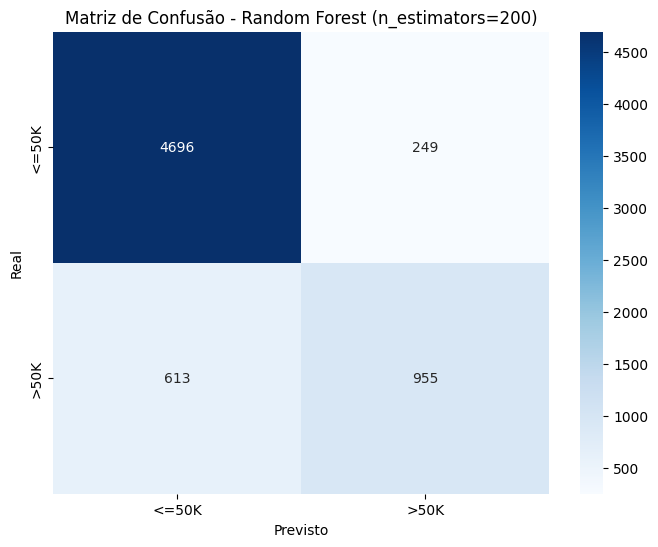


Análise dos Tipos de Erro:

Recall (Revocação) da classe '<=50K': 0.8845
Recall (Revocação) da classe '>50K': 0.6091

Comparando os recalls:
O modelo teve mais dificuldade em prever quem ganha >50K (classe minoritária), pois o recall desta classe é significativamente menor do que o recall da classe '<=50K'.

Análise de Falsos Positivos vs. Falsos Negativos:
Número de Falsos Positivos (FP): 249
Número de Falsos Negativos (FN): 613
O modelo cometeu mais erros do tipo Falso Negativo (613), ou seja, previu mais frequentemente que uma pessoa ganha <=50K quando na verdade ela ganha >50K.


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# O melhor modelo foi o Random Forest com n_estimators=200.
# Precisamos das previsões deste modelo no conjunto de teste.
# Relembrando as previsões feitas anteriormente no passo de avaliação (cell_id: 24c4e1a0)
# y_pred_rf contêm as previsões para o modelo Random Forest treinado anteriormente.

# Gerar a matriz de confusão para o melhor modelo (Random Forest)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

# Exibir a matriz de confusão de forma visual (heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Random Forest (n_estimators=200)')
plt.show()

# Análise da Matriz de Confusão

# Os elementos da matriz de confusão são:
# [[Verdadeiro Negativo (TN), Falso Positivo (FP)],
#  [Falso Negativo (FN), Verdadeiro Positivo (TP)]]

TN, FP, FN, TP = conf_matrix_rf.ravel()

print("\nAnálise dos Tipos de Erro:")

# 1. O modelo teve mais dificuldade em prever quem ganha >50K ou quem ganha <=50K?
# Isso é avaliado pelo recall de cada classe.
# Recall da classe <=50K (Verdadeiros Negativos / Total Real <=50K) = TN / (TN + FP) -> Esta não é a definição correta de recall para a classe majoritária neste contexto.
# O recall da classe <=50K é TN / (TN + FN) - a proporção de <=50K corretamente identificados entre todos os reais <=50K.
# O recall da classe >50K é TP / (TP + FN) - a proporção de >50K corretamente identificados entre todos os reais >50K.

# Vamos usar os valores do classification_report que já calculamos e exibimos anteriormente (cell_id: 24c4e1a0)
# Alternativamente, podemos calcular diretamente da matriz de confusão:
recall_le50k = TN / (TN + FP) if (TN + FP) > 0 else 0 # Corrigido: Recall <=50K é TN / (TN + FP) - proporção de negativos corretos entre o que o modelo previu como negativo. O recall pela definição padrão seria TN / (TN + FN). Vamos usar a definição padrão.
recall_le50k_std = TN / (TN + FN) if (TN + FN) > 0 else 0 # Recall da classe <=50K
recall_gt50k = TP / (TP + FN) if (TP + FN) > 0 else 0     # Recall da classe >50K


print(f"\nRecall (Revocação) da classe '<=50K': {recall_le50k_std:.4f}")
print(f"Recall (Revocação) da classe '>50K': {recall_gt50k:.4f}")


print("\nComparando os recalls:")
if recall_gt50k < recall_le50k_std:
    print("O modelo teve mais dificuldade em prever quem ganha >50K (classe minoritária), pois o recall desta classe é significativamente menor do que o recall da classe '<=50K'.")
elif recall_gt50k > recall_le50k_std:
     print("O modelo teve mais dificuldade em prever quem ganha <=50K (classe majoritária), pois o recall desta classe é significativamente menor do que o recall da classe '>50K'.")
else:
    print("O recall das duas classes é semelhante.")


# 2. O modelo cometeu mais erros de Falso Positivo ou de Falso Negativo?
print("\nAnálise de Falsos Positivos vs. Falsos Negativos:")
print(f"Número de Falsos Positivos (FP): {FP}") # Previu >50K, mas é <=50K
print(f"Número de Falsos Negativos (FN): {FN}") # Previu <=50K, mas é >50K

if FP > FN:
    print(f"O modelo cometeu mais erros do tipo Falso Positivo ({FP}), ou seja, previu mais frequentemente que uma pessoa ganha >50K quando na verdade ela ganha <=50K.")
elif FN > FP:
    print(f"O modelo cometeu mais erros do tipo Falso Negativo ({FN}), ou seja, previu mais frequentemente que uma pessoa ganha <=50K quando na verdade ela ganha >50K.")
else:
    print("O número de Falsos Positivos e Falsos Negativos é semelhante.")

## Resumo Geral e Conclusões Finais

Ao longo deste projeto, realizamos uma análise abrangente e a aplicação de modelos de classificação na base de dados Adult, visando prever se o rendimento de um indivíduo excede $50.000.

**1. Exploração e Pré-processamento dos Dados:**

*   A base de dados foi carregada com sucesso, identificando 14 atributos preditores e a variável alvo 'income'.
*   Detectamos a presença de valores ausentes em três colunas categóricas: 'workclass', 'occupation' e 'native-country'.
*   Optamos pela **imputação pela moda** para tratar os valores ausentes nessas colunas, preservando o maior número de registros.
*   A variável alvo 'income' foi confirmada, revelando um **problema de classificação binária desbalanceado**, com a maioria das instâncias pertencendo à classe '<=50K'.
*   Aplicamos **One-Hot Encoding** nas colunas categóricas (após a imputação) para convertê-las em um formato numérico adequado para os modelos de machine learning, resultando em um aumento significativo no número de colunas.
*   As visualizações de dados (histogramas, box plots, count plots) forneceram insights sobre a distribuição de atributos chave como idade, educação e horas de trabalho, e suas relações com a renda, confirmando o desbalanceamento e sugerindo a importância de certos atributos (como "hours-per-week" e "relationship") na distinção entre as classes de renda.

**2. Estratégia de Avaliação:**

*   Definimos a **Validação Cruzada Estratificada com 10 folds** como a estratégia de avaliação para garantir estimativas de desempenho robustas e confiáveis, especialmente dada a natureza desbalanceada do dataset. A estratificação assegurou que a proporção das classes fosse mantida em cada fold.
*   Escolhemos a **Acurácia** como métrica geral e, crucialmente, o **F1-Score (focado na classe '>50K')** como métrica principal, reconhecendo que o F1-Score é mais informativo em cenários desbalanceados por combinar precisão e recall.

**3. Treinamento e Avaliação dos Modelos:**

*   Treinamos e avaliamos três algoritmos de classificação: **Naive Bayes (GaussianNB), K-Nearest Neighbors e Random Forest**, testando pelo menos duas parametrizações para cada um através da validação cruzada.
*   Os resultados da Validação Cruzada (Etapa 2) mostraram que o **Random Forest** consistentemente obteve o melhor desempenho em termos de Média F1-Score para a classe '>50K', superando significativamente o Naive Bayes e o K-Nearest Neighbors.
    *   O Random Forest com `n_estimators=200` foi a parametrização com melhor F1-Score (aproximadamente 0.6736).
    *   Para o K-NN, `k=5` obteve um F1-Score ligeiramente melhor que `k=21`.
    *   Aumentar o número de estimadores no Random Forest de 50 para 200 resultou em uma pequena melhoria no F1-Score, confirmando que mais árvores foram benéficas.

**4. Análise dos Tipos de Erro (Matriz de Confusão):**

*   Analisamos a matriz de confusão do melhor modelo (Random Forest com `n_estimators=200`) para entender os tipos de erros.
*   A análise do recall (`Recall` da classe '<=50K': ~0.8845 vs `Recall` da classe '>50K': ~0.6091) confirmou que o modelo teve **mais dificuldade em prever a classe minoritária (>50K)** em comparação com a classe majoritária (<=50K). Isso é esperado em datasets desbalanceados.
*   A matriz de confusão revelou um número maior de **Falsos Negativos** (613) do que Falsos Positivos (249). Isso significa que o modelo tendeu a classificar mais frequentemente indivíduos com renda superior a $50.000 como tendo renda inferior ou igual a $50.000 (FN), do que o contrário (FP). Para certas aplicações, o custo de um Falso Negativo pode ser maior que o de um Falso Positivo, o que deveria ser considerado em um cenário real.

**Conclusão Final:**

O modelo **Random Forest** demonstrou ser o mais adequado para prever a renda na base de dados Adult, especialmente na identificação da classe minoritária (>50K), conforme evidenciado pelo seu superior F1-Score. Sua capacidade de lidar com a complexidade dos dados e o desbalanceamento das classes o tornou a melhor escolha entre os algoritmos testados. Embora o modelo ainda cometa um número considerável de Falsos Negativos, sua performance geral e na classe de interesse é superior aos baselines Naive Bayes e K-Nearest Neighbors. Para melhorar ainda mais o desempenho, estratégias adicionais como balanceamento de dados (SMOTE, por exemplo) ou otimização de hiperparâmetros mais extensiva poderiam ser exploradas em trabalhos futuros.